# Setul de date Abalone – Vizualizarea funcției de activare Sigmoid

Acest notebook:
1. Descarcă setul de date **Abalone** de la UCI
2. Preprocesează datele (one-hot encoding, normalizare)
3. Vizualizează **funcția sigmoid** pe inputurile nete ale unui neuron simplu antrenat pe aceste date


In [1]:
# ── 1. Importuri ──────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

print('Librăriile au fost importate cu succes.')

Librăriile au fost importate cu succes.


In [2]:
# ── 2. Descărcarea setului de date Abalone de la UCI ─────────────────────────
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/abalone/abalone.data'
columns = ['Sex', 'Length', 'Diameter', 'Height', 'Whole_weight',
           'Shucked_weight', 'Viscera_weight', 'Shell_weight', 'Rings']

df = pd.read_csv(url, header=None, names=columns)
print(f'Shape: {df.shape}')
df.head()

Shape: (4177, 9)


,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [3]:
# ── 3. Preprocesare ───────────────────────────────────────────────────────────
# One-hot encoding pentru coloana 'Sex' (M, F, I)
df_enc = pd.get_dummies(df, columns=['Sex'], drop_first=False)

# Variabila țintă binară: 1 dacă Rings > median, 0 altfel
median_rings = df_enc['Rings'].median()
y = (df_enc['Rings'] > median_rings).astype(int).values
X = df_enc.drop(columns=['Rings']).values.astype(float)

# Normalizare Min-Max
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Median Rings: {median_rings}')

Train: (3341, 10), Test: (836, 10)
Median Rings: 9.0


In [4]:
# ── 4. Antrenarea unui model logistic (neuron cu activare sigmoid) ────────────
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)
acc = model.score(X_test, y_test)
print(f'Acuratețe pe setul de test: {acc:.4f}')

Acuratețe pe setul de test: 0.7703


In [5]:
# ── 5. Funcția sigmoid și derivata sa ────────────────────────────────────────
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)

# Inputurile nete (z = X @ w + b) pentru setul de test
z_test = X_test @ model.coef_.T + model.intercept_   # shape (n, 1)
z_test_flat = z_test.flatten()

# Grilă continuă pentru curba teoretică
z_range = np.linspace(-8, 8, 500)

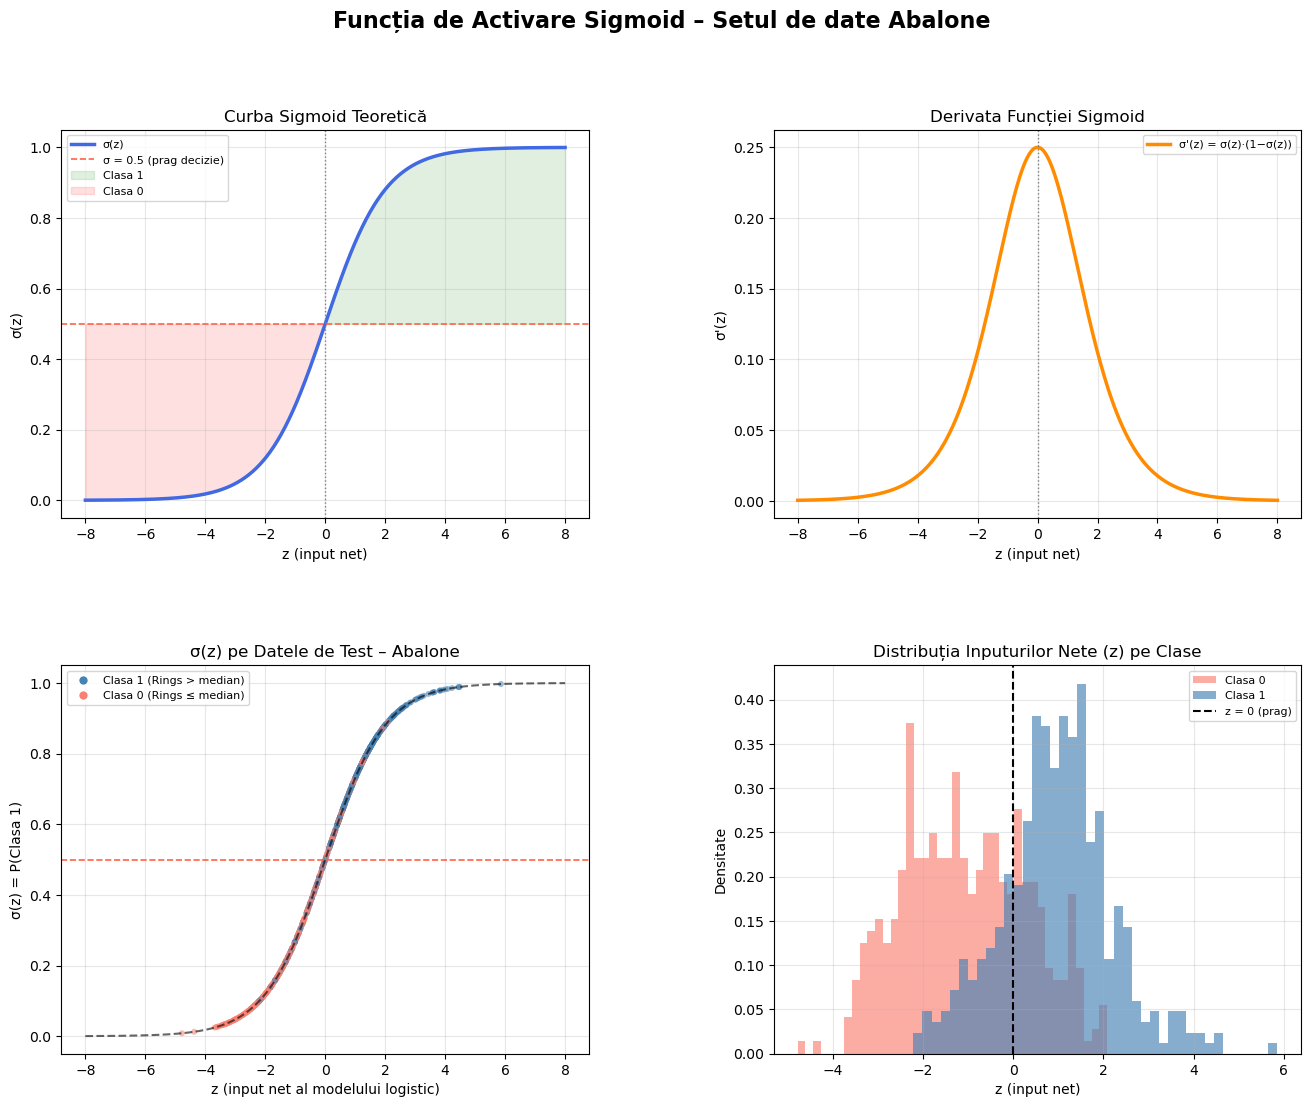

Graficul a fost salvat ca abalone_sigmoid.png


In [6]:
# ── 6. Vizualizare completă ───────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
fig.suptitle('Funcția de Activare Sigmoid – Setul de date Abalone',
             fontsize=16, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.35)

# ── Subplot 1: Curba sigmoid teoretică ───────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(z_range, sigmoid(z_range), color='royalblue', lw=2.5, label='σ(z)')
ax1.axhline(0.5, color='tomato', ls='--', lw=1.2, label='σ = 0.5 (prag decizie)')
ax1.axvline(0,   color='gray',   ls=':',  lw=1.0)
ax1.fill_between(z_range, sigmoid(z_range), 0.5,
                 where=(sigmoid(z_range) > 0.5), alpha=0.12, color='green', label='Clasa 1')
ax1.fill_between(z_range, sigmoid(z_range), 0.5,
                 where=(sigmoid(z_range) < 0.5), alpha=0.12, color='red',   label='Clasa 0')
ax1.set_title('Curba Sigmoid Teoretică', fontsize=12)
ax1.set_xlabel('z (input net)')
ax1.set_ylabel('σ(z)')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(-0.05, 1.05)

# ── Subplot 2: Derivata sigmoid ───────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(z_range, sigmoid_derivative(z_range), color='darkorange', lw=2.5,
         label="σ'(z) = σ(z)·(1−σ(z))")
ax2.axvline(0, color='gray', ls=':', lw=1.0)
ax2.set_title('Derivata Funcției Sigmoid', fontsize=12)
ax2.set_xlabel('z (input net)')
ax2.set_ylabel("σ'(z)")
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# ── Subplot 3: Distribuția inputurilor nete pe datele Abalone ─────────────────
ax3 = fig.add_subplot(gs[1, 0])
colors_map = np.where(y_test == 1, 'steelblue', 'salmon')
ax3.scatter(z_test_flat, sigmoid(z_test_flat),
            c=colors_map, alpha=0.55, s=18, edgecolors='none')
ax3.plot(z_range, sigmoid(z_range), color='black', lw=1.5, ls='--', alpha=0.6)
ax3.axhline(0.5, color='tomato', ls='--', lw=1.2)
ax3.set_title('σ(z) pe Datele de Test – Abalone', fontsize=12)
ax3.set_xlabel('z (input net al modelului logistic)')
ax3.set_ylabel('σ(z) = P(Clasa 1)')
# Legendă manuală
from matplotlib.lines import Line2D
legend_els = [Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue',
                     markersize=7, label='Clasa 1 (Rings > median)'),
              Line2D([0],[0], marker='o', color='w', markerfacecolor='salmon',
                     markersize=7, label='Clasa 0 (Rings ≤ median)')]
ax3.legend(handles=legend_els, fontsize=8)
ax3.grid(True, alpha=0.3)

# ── Subplot 4: Histograma inputurilor nete pe clase ───────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
ax4.hist(z_test_flat[y_test == 0], bins=40, color='salmon',
         alpha=0.65, label='Clasa 0', density=True)
ax4.hist(z_test_flat[y_test == 1], bins=40, color='steelblue',
         alpha=0.65, label='Clasa 1', density=True)
ax4.axvline(0, color='black', ls='--', lw=1.5, label='z = 0 (prag)')
ax4.set_title('Distribuția Inputurilor Nete (z) pe Clase', fontsize=12)
ax4.set_xlabel('z (input net)')
ax4.set_ylabel('Densitate')
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3)

plt.savefig('abalone_sigmoid.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graficul a fost salvat ca abalone_sigmoid.png')

## Interpretare

| Grafic | Descriere |
|--------|-----------|
| **Curba sigmoid teoretică** | σ(z) = 1/(1+e⁻ᶻ) — transformă orice valoare reală în intervalul (0, 1). Pragul de decizie implicit este σ = 0.5, adică z = 0. |
| **Derivata sigmoid** | σ'(z) = σ(z)·(1−σ(z)) — maximă în z=0 (≈0.25). Esențial în backpropagation; valori mici la extreme → *vanishing gradient*. |
| **σ(z) pe datele Abalone** | Fiecare punct este o mostră din setul de test; culoarea indică clasa reală. Separarea vizibilă confirmă că modelul logistic discriminează bine. |
| **Histograma z pe clase** | Distribuțiile inputurilor nete pentru cele două clase; suprapunerea arată zona de incertitudine a modelului. |
